In [1]:
import numpy as np 
import pandas as pd
import joblib

### Load models

In [2]:
lr_balanced_pipeline=joblib.load("../models/logistic_cw_pipeline.pkl")
lr_smote_pipeline=joblib.load("../models/logistic_smote_pipeline.pkl")
random_forest=joblib.load("../models/random_forest.pkl")
random_forest_tuned=joblib.load("../models/random_forest_tuned.pkl")
xgboost=joblib.load("../models/xgboost.pkl")

### Load test data

In [3]:
x_train,x_test,y_train,y_test=joblib.load("../data/processed/split_data.pkl")

### Create model dictinary

This helps in evaluating models easily

In [4]:
models= {
    "Logistic regression(class weight)" : lr_balanced_pipeline,
    "Logistic regression(SMOTE)" : lr_smote_pipeline,
    "Random forest" : random_forest,
    "Random forest tuned" :random_forest_tuned,
    "XGBoost" : xgboost
}

### Evaluate all models

In [5]:
from sklearn.metrics import recall_score,f1_score,accuracy_score,precision_score
import pandas as pd

results=[]

for name, model in models.items():
    y_pred= model.predict(x_test)

    accuracy=accuracy_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    precision= precision_score(y_test,y_pred)

    results.append({
        'Model':name,
        'Accuracy':accuracy,
        "recall":recall,
        "F1 score":f1,
        "precision":precision
    })

results_df=pd.DataFrame(results)

results_df


,Model,Accuracy,recall,F1 score,precision
0,Logistic regression(class weight),0.726368,0.796791,0.607543,0.490939
1,Logistic regression(SMOTE),0.732054,0.780749,0.607700,0.497445
2,Random forest,0.786070,0.502674,0.555391,0.620462
3,Random forest tuned,0.759062,0.754011,0.624585,0.533081
4,XGBoost,0.758351,0.537433,0.541779,0.546196


### Conclusion

Multiple models were trained and evaluated, including Logistic Regression 
(with class weighting and SMOTE), Random Forest, tuned Random Forest, and XGBoost.

Among these models, the **tuned Random Forest model** achieved the best overall 
performance based on evaluation metrics such as Accuracy, Recall, and F1 Score.

Since the objective of this project is to correctly identify customers likely 
to churn, the model with the best balance between recall and F1-score for the 
churn class was selected as the final model.

Therefore, the **tuned Random Forest model** was chosen as the final model for 
customer churn prediction.

### ROC-AUC Curve

The ROC-AUC curve evaluates model's ability to distinguish between the churn and non-churn customers. 
The curve plots the True positive rate against false positive rate at different classification thresholds. 
A higher auc score indicates better model performance.
This visualization helps to compare classification performance of muliple models.

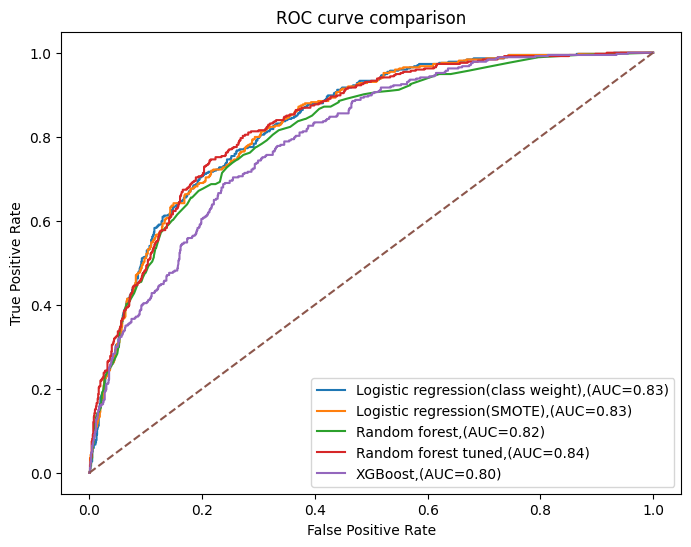

In [14]:
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name,model in models.items():

    y_prob = model.predict_proba(x_test)[:,-1]

    fpr, tpr, _ = roc_curve(y_test,y_prob)

    roc_auc=auc(fpr,tpr)

    plt.plot(fpr,tpr, label=f"{name},(AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve comparison")
plt.legend()

plt.show()

The tuned random forest model achieved the best overall performance with the highest roc-auc score, indicating strong ability to distinguish between churn and non-churn customers.

### Confusion Matrix

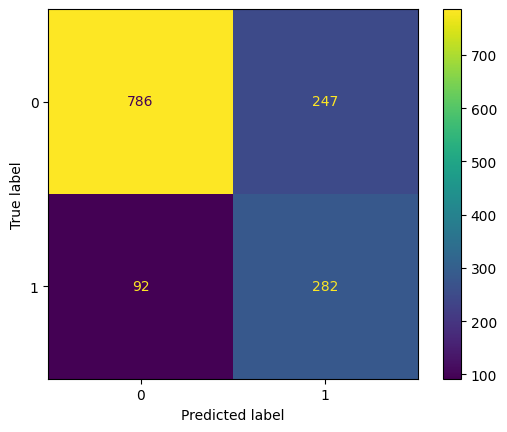

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator( random_forest_tuned,x_test,y_test)

 ### Feature importance analysis

 To understand the factors influencing customer churn, feature importance was analyed using the tuned random forest model. Random Forest provides a natural measure of feature importance based on how much each feature contributes to reducing impurity across decision trees.

 This analysis helps to identify the most influencial variables affecting churn predictions and provides valuble insights for business decision-making.

In [22]:
import pandas as pd


feature_importance= pd.DataFrame({
    "Feature" : x_train.columns,
    "Importance" : random_forest_tuned.feature_importances_
})

feature_importance= feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(10)

,Feature,Importance
1,tenure,0.179304
3,TotalCharges,0.138786
25,Contract_Two year,0.112451
2,MonthlyCharges,0.095432
10,InternetService_Fiber optic,0.070216
28,PaymentMethod_Electronic check,0.053686
24,Contract_One year,0.045008
13,OnlineSecurity_Yes,0.036445
19,TechSupport_Yes,0.023251
18,TechSupport_No internet service,0.018003


##### Visualization

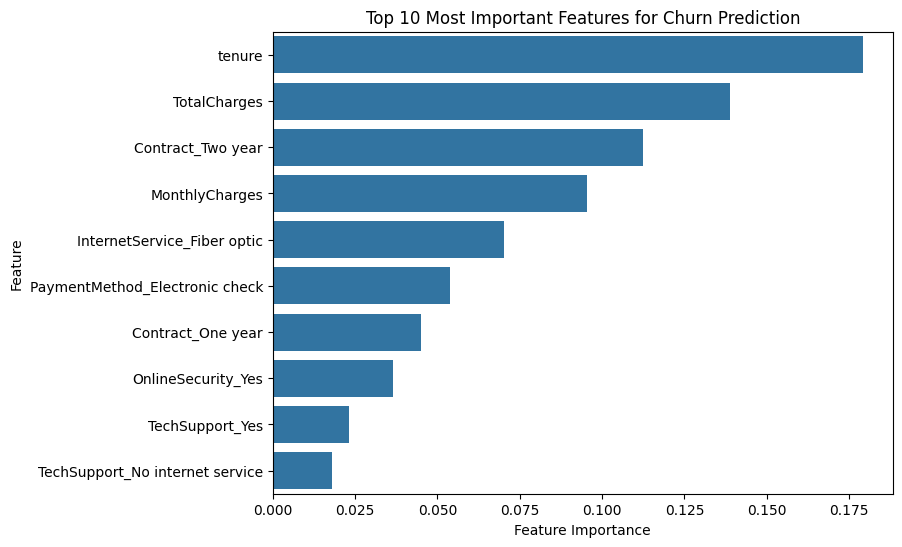

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features for Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

#### Save the best model to the model

In [11]:
joblib.dump(random_forest_tuned,"../models/final_churn_model.pkl")

['../models/final_churn_model.pkl']